In [1]:
print("hola")

hola


# **1. Configutación**

In [2]:
from pathlib import Path
import json
import random

import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


PREPARED_DIR = Path(
    "/content/drive/MyDrive/dataset-LZUPSD/prepared_3"
)

DATASET_DIR = Path(
    "/content/Seed_dataset_extracted/Seed dataset"
)

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/dataset-LZUPSD/finetuning_outputs"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


NUM_CLASSES = 88
IMAGE_SIZE = 224

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


print("=== E3 — Fine-Tuning ligero de BioCLIP ===\n")

print(f"Seed:              {SEED}")
print(f"Dispositivo:       {device}")
print(f"Número de clases:  {NUM_CLASSES}")
print(f"Tamaño de imagen:  {IMAGE_SIZE}x{IMAGE_SIZE}")

print("\nRutas:")
print(f"PREPARED_DIR:      {PREPARED_DIR}")
print(f"DATASET_DIR:       {DATASET_DIR}")
print(f"OUTPUT_DIR:        {OUTPUT_DIR}")

print("\nGPU disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

=== E3 — Fine-Tuning ligero de BioCLIP ===

Seed:              42
Dispositivo:       cuda
Número de clases:  88
Tamaño de imagen:  224x224

Rutas:
PREPARED_DIR:      /content/drive/MyDrive/dataset-LZUPSD/prepared_3
DATASET_DIR:       /content/Seed_dataset_extracted/Seed dataset
OUTPUT_DIR:        /content/drive/MyDrive/dataset-LZUPSD/finetuning_outputs

GPU disponible: True
GPU: Tesla T4


# **2. Cargar Splits**

In [5]:
import os
import shutil
from pathlib import Path
from google.colab import drive

# 1. Desmontar y Montar Google Drive para asegurar una vista fresca
if os.path.exists('/content/drive'):
    print("Intentando desmontar Google Drive...")
    try:
        drive.flush_and_unmount()
        print("Google Drive desmontado.")
    except RuntimeError as e:
        print(f"Error al desmontar (posiblemente ya desmontado): {e}.")

    # Asegurarse de que el punto de montaje esté vacío
    if os.path.exists('/content/drive') and os.path.isdir('/content/drive') and os.listdir('/content/drive'):
        print("Limpiando el directorio de montaje /content/drive...")
        try:
            # Eliminar el contenido, pero no el directorio mismo si es el mountpoint
            for item in os.listdir('/content/drive'):
                item_path = os.path.join('/content/drive', item)
                if os.path.isfile(item_path) or os.path.islink(item_path):
                    os.remove(item_path)
                elif os.path.isdir(item_path):
                    shutil.rmtree(item_path)
            print("Contenido de /content/drive limpiado.")
        except OSError as e:
            print(f"Error al limpiar /content/drive: {e}. Esto podría ser normal si ya está vacío o no es accesible.")

print("Montando Google Drive con force_remount=True...")
drive.mount('/content/drive', force_remount=True)
print("Google Drive montado.")

# 2. Ruta raíz general
drive_root = Path("/content/drive/MyDrive")

print("=" * 80)
print("📂 EXPLORACIÓN COMPLETA DE GOOGLE DRIVE (CARPETAS Y ARCHIVOS)")
print("=" * 80)

if drive_root.exists():
    print(f"Ruta raíz base: {drive_root}\n")

    for root, dirs, files in os.walk(drive_root):
        current_path = Path(root)

        # Filtrar elementos ocultos del sistema
        dirs[:] = [d for d in dirs if not d.startswith('.')]
        files = [f for f in files if not f.startswith('.')]

        depth = len(current_path.relative_to(drive_root).parts)
        indent = "│   " * depth

        if depth == 0:
            print(f"📁 MyDrive/ ({current_path})")
        else:
            print(f"{indent}├── 📁 {current_path.name}/")

        # Imprimir todos los archivos dentro de cada carpeta
        for file in files:
            file_path = current_path / file
            try:
                # Tamaño en MB (o KB si es muy pequeño)
                size_bytes = file_path.stat().st_size
                if size_bytes >= 1024 * 1024:
                    size_str = f"{size_bytes / (1024 * 1024):.2f} MB"
                else:
                    size_str = f"{size_bytes / 1024:.1f} KB"
            except Exception:
                size_str = "tamaño no disponible"

            print(f"{indent}│   ├── 📄 {file} ({size_str})")

    print("\n" + "=" * 80)
    print("✅ Exploración completa finalizada exitosamente.")
else:
    print("❌ No se pudo acceder a Google Drive. Revisa la conexión del montaje.")

Intentando desmontar Google Drive...
Drive not mounted, so nothing to flush and unmount.
Google Drive desmontado.
Limpiando el directorio de montaje /content/drive...
Contenido de /content/drive limpiado.
Montando Google Drive con force_remount=True...
Mounted at /content/drive
Google Drive montado.
📂 EXPLORACIÓN COMPLETA DE GOOGLE DRIVE (CARPETAS Y ARCHIVOS)
Ruta raíz base: /content/drive/MyDrive

📁 MyDrive/ (/content/drive/MyDrive)
│   ├── 📄 PROYECTO DE ASIGNATURA (1) (2).docx (9.60 MB)
│   ├── 📄 IMG_20250228_194910.jpg (2.09 MB)
│   ├── 📁 Colab Notebooks/
│   │   ├── 📄 ProyectVisionComputer.ipynb (275.7 KB)
│   │   ├── 📄 Untitled0.ipynb (0.3 KB)
│   │   ├── 📄 Copy of 01_eda_dataset.ipynb (7.51 MB)
│   │   ├── 📄 Copy of 02_prepare_split.ipynb (63.8 KB)
│   │   ├── 📄 Copy of 03_bioclip_zeroshot.ipynb (85.6 KB)
│   │   ├── 📄 Copy of 04_bioclip_linearprobe.ipynb (681.1 KB)
│   ├── 📁 dataset-LZUPSD/
│   │   ├── 📄 Seed dataset.zip (66.60 MB)
│   │   ├── 📁 prepared_1/
│   │   │   ├── 📄 tra

In [8]:
import pandas as pd
import os
from google.colab import drive

# The drive should already be mounted by the previous cell, so this check is mostly redundant now
# but good practice if this cell were run in isolation.
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

train_df = pd.read_csv(PREPARED_DIR / "train.csv")
val_df = pd.read_csv(PREPARED_DIR / "val.csv")
test_df = pd.read_csv(PREPARED_DIR / "test.csv")

print("=== Tamaño de los splits ===\n")

print(f"Train:       {len(train_df):,}")
print(f"Validation:  {len(val_df):,}")
print(f"Test:        {len(test_df):,}")

print("\n=== Columnas ===")
print(train_df.columns.tolist())

print("\n=== Número de clases ===")

print(f"Train:       {train_df['class_id'].nunique()}")
print(f"Validation:  {val_df['class_id'].nunique()}")
print(f"Test:        {test_df['class_id'].nunique()}")

print("\n=== Verificación de IDs ===")

train_classes = set(train_df["class_id"])
val_classes = set(val_df["class_id"])
test_classes = set(test_df["class_id"])

print(f"Train = Validation: {train_classes == val_classes}")
print(f"Train = Test:       {train_classes == test_classes}")

print("\n=== Rango de class_id ===")
print(
    f"{train_df['class_id'].min()} - "
    f"{train_df['class_id'].max()}"
)

=== Tamaño de los splits ===

Train:       3,145
Validation:  674
Test:        674

=== Columnas ===
['image_path', 'class_name', 'class_id']

=== Número de clases ===
Train:       88
Validation:  88
Test:        88

=== Verificación de IDs ===
Train = Validation: True
Train = Test:       True

=== Rango de class_id ===
0 - 87


# **3. Cargar BioCLIP**

In [9]:
!pip install open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.0 MB/s eta 0:00:00


In [10]:
import open_clip

MODEL_ID = "hf-hub:imageomics/bioclip"

model, preprocess_train, preprocess_val = (
    open_clip.create_model_and_transforms(MODEL_ID)
)

tokenizer = open_clip.get_tokenizer(MODEL_ID)

model = model.to(device)

print("=== BioCLIP cargado ===\n")
print(f"Modelo:        {MODEL_ID}")
print(f"Dispositivo:   {device}")
print(f"Modo training: {model.training}")
print(f"Modo eval:     {not model.training}")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


open_clip_config.json:   0%|          | 0.00/469 [00:00<?, ?B/s]

open_clip_pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  599MB            

open_clip_pytorch_model.bin: downloading bytes:           |  0.00B            

=== BioCLIP cargado ===

Modelo:        hf-hub:imageomics/bioclip
Dispositivo:   cuda
Modo training: True
Modo eval:     False


# **4. Inspección del encoder visual**

In [11]:
print("=== Arquitectura del encoder visual ===\n")

print(model.visual)

=== Arquitectura del encoder visual ===

VisionTransformer(
  (conv1): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), bias=False)
  (patch_dropout): Identity()
  (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (transformer): Transformer(
    (resblocks): ModuleList(
      (0-11): 12 x ResidualAttentionBlock(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (ls_1): Identity()
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): Sequential(
          (c_fc): Linear(in_features=768, out_features=3072, bias=True)
          (gelu): GELU(approximate='none')
          (c_proj): Linear(in_features=3072, out_features=768, bias=True)
        )
        (ls_2): Identity()
      )
    )
  )
  (ln_post): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)


# **5. Contar parámetros por bloque**

In [12]:
print("=== Parámetros por bloque Transformer ===\n")

for block_idx, block in enumerate(model.visual.transformer.resblocks):

    block_params = sum(
        p.numel()
        for p in block.parameters()
    )

    print(
        f"Bloque {block_idx:2d}: "
        f"{block_params:,} parámetros"
    )

print("\n=== Parámetros del encoder visual completo ===")

visual_total_params = sum(
    p.numel()
    for p in model.visual.parameters()
)

print(f"Total encoder visual: {visual_total_params:,}")

=== Parámetros por bloque Transformer ===

Bloque  0: 7,087,872 parámetros
Bloque  1: 7,087,872 parámetros
Bloque  2: 7,087,872 parámetros
Bloque  3: 7,087,872 parámetros
Bloque  4: 7,087,872 parámetros
Bloque  5: 7,087,872 parámetros
Bloque  6: 7,087,872 parámetros
Bloque  7: 7,087,872 parámetros
Bloque  8: 7,087,872 parámetros
Bloque  9: 7,087,872 parámetros
Bloque 10: 7,087,872 parámetros
Bloque 11: 7,087,872 parámetros

=== Parámetros del encoder visual completo ===
Total encoder visual: 86,192,640


Para mantener el experimento realmente ligero y controlado, propongo descongelar únicamente los dos últimos bloques Transformer: 10 y 11, manteniendo congelados:

- conv1
- ln_pre
- bloques 0–9
- y el resto del encoder que no necesitemos adaptar.

Esto nos permite evaluar una adaptación limitada del conocimiento visual de BioCLIP a LZUPSD, sin convertir el experimento en un fine-tuning completo de los ~150 millones de parámetros.

Pero hay una cuestión importante

Antes de descongelar los bloques necesitamos saber cuántos parámetros representa realmente esta decisión.


# **6. Verificación de dimensiones**

In [13]:
import torch


dummy_input = torch.randn(
    1, 3, IMAGE_SIZE, IMAGE_SIZE,
    device=device
)

print("=== Entrada ===")
print(f"Shape:  {tuple(dummy_input.shape)}")
print(f"Dtype:  {dummy_input.dtype}")
print(f"Device: {dummy_input.device}")


model.eval()

with torch.inference_mode():

    image_features = model.encode_image(dummy_input)

print("\n=== Salida de model.encode_image() ===")
print(f"Shape:  {tuple(image_features.shape)}")
print(f"Dtype:  {image_features.dtype}")
print(f"Device: {image_features.device}")


with torch.inference_mode():

    visual_features = model.visual(dummy_input)

print("\n=== Salida de model.visual() ===")
print(f"Shape:  {tuple(visual_features.shape)}")
print(f"Dtype:  {visual_features.dtype}")
print(f"Device: {visual_features.device}")

print("\n=== Verificaciones ===")

print(
    "NaN en encode_image:",
    torch.isnan(image_features).any().item()
)

print(
    "Inf en encode_image:",
    torch.isinf(image_features).any().item()
)

print(
    "NaN en visual:",
    torch.isnan(visual_features).any().item()
)

print(
    "Inf en visual:",
    torch.isinf(visual_features).any().item()
)

=== Entrada ===
Shape:  (1, 3, 224, 224)
Dtype:  torch.float32
Device: cuda:0

=== Salida de model.encode_image() ===
Shape:  (1, 512)
Dtype:  torch.float32
Device: cuda:0

=== Salida de model.visual() ===
Shape:  (1, 512)
Dtype:  torch.float32
Device: cuda:0

=== Verificaciones ===
NaN en encode_image: False
Inf en encode_image: False
NaN en visual: False
Inf en visual: False


# **7. Crear la cabeza de clasificació**

In [14]:
import torch.nn as nn

EMBEDDING_DIM = 512

classifier = nn.Linear(
    EMBEDDING_DIM,
    NUM_CLASSES
)

classifier = classifier.to(device)

classifier_params = sum(
    p.numel()
    for p in classifier.parameters()
)

print("=== Cabeza de clasificación ===\n")

print(classifier)

print(f"\nDimensión de entrada:  {EMBEDDING_DIM}")
print(f"Número de clases:      {NUM_CLASSES}")
print(f"Parámetros:            {classifier_params:,}")

# Verificación con una representación ficticia
dummy_embedding = torch.randn(
    1,
    EMBEDDING_DIM,
    device=device
)

dummy_logits = classifier(dummy_embedding)

print("\n=== Verificación ===")
print(f"Embedding: {tuple(dummy_embedding.shape)}")
print(f"Logits:    {tuple(dummy_logits.shape)}")

=== Cabeza de clasificación ===

Linear(in_features=512, out_features=88, bias=True)

Dimensión de entrada:  512
Número de clases:      88
Parámetros:            45,144

=== Verificación ===
Embedding: (1, 512)
Logits:    (1, 88)


# **8. Configurar parámetros congelados y entrenables**

In [15]:
for param in model.parameters():
    param.requires_grad = False


for block_idx in [10, 11]:

    for param in model.visual.transformer.resblocks[block_idx].parameters():
        param.requires_grad = True


for param in classifier.parameters():
    param.requires_grad = True


bioclip_total_params = sum(
    p.numel()
    for p in model.parameters()
)

bioclip_trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

bioclip_frozen_params = (
    bioclip_total_params - bioclip_trainable_params
)

classifier_trainable_params = sum(
    p.numel()
    for p in classifier.parameters()
    if p.requires_grad
)

total_trainable_params = (
    bioclip_trainable_params +
    classifier_trainable_params
)

print("=== Configuración de Fine-Tuning ligero ===\n")

print("BioCLIP")
print(f"Parámetros totales:      {bioclip_total_params:,}")
print(f"Parámetros entrenables:  {bioclip_trainable_params:,}")
print(f"Parámetros congelados:   {bioclip_frozen_params:,}")

print("\nBloques entrenables:")
print("Transformer block 10")
print("Transformer block 11")

print("\nClasificador")
print(f"Parámetros entrenables:  {classifier_trainable_params:,}")

print("\n=== Total del experimento ===")
print(f"Parámetros entrenables:  {total_trainable_params:,}")

print("\n=== Verificación por bloque ===")

for block_idx, block in enumerate(
    model.visual.transformer.resblocks
):

    trainable = sum(
        p.numel()
        for p in block.parameters()
        if p.requires_grad
    )

    status = (
        "ENTRENABLE"
        if trainable > 0
        else "CONGELADO"
    )

    print(
        f"Bloque {block_idx:2d}: "
        f"{status}"
    )

=== Configuración de Fine-Tuning ligero ===

BioCLIP
Parámetros totales:      149,620,737
Parámetros entrenables:  14,175,744
Parámetros congelados:   135,444,993

Bloques entrenables:
Transformer block 10
Transformer block 11

Clasificador
Parámetros entrenables:  45,144

=== Total del experimento ===
Parámetros entrenables:  14,220,888

=== Verificación por bloque ===
Bloque  0: CONGELADO
Bloque  1: CONGELADO
Bloque  2: CONGELADO
Bloque  3: CONGELADO
Bloque  4: CONGELADO
Bloque  5: CONGELADO
Bloque  6: CONGELADO
Bloque  7: CONGELADO
Bloque  8: CONGELADO
Bloque  9: CONGELADO
Bloque 10: ENTRENABLE
Bloque 11: ENTRENABLE


# **9. Crear el modelo de clasificación**

In [16]:
class BioCLIPClassifier(nn.Module):
    """
    Modelo de clasificación basado en BioCLIP.

    BioCLIP proporciona la representación visual de 512 dimensiones
    y una capa lineal transforma esa representación en logits para
    las 88 clases de LZUPSD.
    """

    def __init__(self, bioclip_model, classifier):
        super().__init__()

        self.bioclip = bioclip_model
        self.classifier = classifier

    def forward(self, images):

        features = self.bioclip.encode_image(images)

        logits = self.classifier(features)

        return logits


finetuning_model = BioCLIPClassifier(
    model,
    classifier
).to(device)

print("=== Modelo de clasificación creado ===\n")

print(f"Tipo de modelo: {type(finetuning_model).__name__}")

print("\nComponentes:")
print("- BioCLIP visual encoder")
print("- Linear classifier: 512 → 88")

total_trainable = sum(
    p.numel()
    for p in finetuning_model.parameters()
    if p.requires_grad
)

total_parameters = sum(
    p.numel()
    for p in finetuning_model.parameters()
)

print("\n=== Parámetros ===")
print(f"Totales:       {total_parameters:,}")
print(f"Entrenables:   {total_trainable:,}")
print(f"Congelados:    {total_parameters - total_trainable:,}")

=== Modelo de clasificación creado ===

Tipo de modelo: BioCLIPClassifier

Componentes:
- BioCLIP visual encoder
- Linear classifier: 512 → 88

=== Parámetros ===
Totales:       149,665,881
Entrenables:   14,220,888
Congelados:    135,444,993


# **10. Crear Dataset y DataLoader**

In [17]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image


class SeedDataset(Dataset):
    """
    Dataset para las imágenes de semillas de LZUPSD.
    """

    def __init__(self, dataframe, dataset_dir, preprocess):
        self.dataframe = dataframe.reset_index(drop=True)
        self.dataset_dir = dataset_dir
        self.preprocess = preprocess

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image_path = self.dataset_dir / row["image_path"]

        image = Image.open(image_path).convert("RGB")

        image = self.preprocess(image)

        label = int(row["class_id"])

        return image, label

train_dataset = SeedDataset(
    train_df,
    DATASET_DIR,
    preprocess_train
)

val_dataset = SeedDataset(
    val_df,
    DATASET_DIR,
    preprocess_val
)

test_dataset = SeedDataset(
    test_df,
    DATASET_DIR,
    preprocess_val
)

BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("=== Datasets ===\n")

print(f"Train:       {len(train_dataset):,}")
print(f"Validation:  {len(val_dataset):,}")
print(f"Test:        {len(test_dataset):,}")

print("\n=== DataLoaders ===")

print(f"Train batches:       {len(train_loader)}")
print(f"Validation batches:  {len(val_loader)}")
print(f"Test batches:        {len(test_loader)}")

print("\n=== Batch size ===")
print(f"{BATCH_SIZE}")

=== Datasets ===

Train:       3,145
Validation:  674
Test:        674

=== DataLoaders ===
Train batches:       99
Validation batches:  22
Test batches:        22

=== Batch size ===
32


# **11. Verificación de un batch**

In [19]:
import zipfile

ZIP_PATH = Path(
    "/content/drive/MyDrive/dataset-LZUPSD/Seed dataset.zip"
)

EXTRACT_DIR = Path(
    "/content/Seed_dataset_extracted"
)

# Si la carpeta no existe, extraer el dataset
if not EXTRACT_DIR.exists():

    print("La carpeta extraída no existe.")
    print("Extrayendo dataset desde Google Drive...\n")

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

    print("Extracción completada.")

else:

    print("La carpeta de extracción ya existe.")


DATASET_DIR = EXTRACT_DIR / "Seed dataset"

print("\n=== Verificación ===")
print(f"Dataset existe: {DATASET_DIR.exists()}")
print(f"Ruta: {DATASET_DIR}")

# Verificar específicamente la imagen que produjo el error
test_image = DATASET_DIR / "Plantago major" / "changed577.jpg"

print(
    f"\nImagen problemática existe: {test_image.exists()}"
)

La carpeta extraída no existe.
Extrayendo dataset desde Google Drive...

Extracción completada.

=== Verificación ===
Dataset existe: True
Ruta: /content/Seed_dataset_extracted/Seed dataset

Imagen problemática existe: True


In [20]:
# Tomar un único batch del conjunto de entrenamiento
images, labels = next(iter(train_loader))

print("=== Batch original ===")
print(f"Imágenes: {tuple(images.shape)}")
print(f"Labels:   {tuple(labels.shape)}")
print(f"Dtype imágenes: {images.dtype}")
print(f"Dtype labels:   {labels.dtype}")

# Mover a GPU
images = images.to(device, non_blocking=True)
labels = labels.to(device, non_blocking=True)

print("\n=== Batch en GPU ===")
print(f"Imágenes: {images.device}")
print(f"Labels:   {labels.device}")

# Modo evaluación solamente para esta prueba
finetuning_model.eval()

with torch.inference_mode():

    logits = finetuning_model(images)

print("\n=== Salida del modelo ===")
print(f"Logits: {tuple(logits.shape)}")
print(f"Dtype: {logits.dtype}")
print(f"Device: {logits.device}")

print("\n=== Verificaciones ===")

print(
    "NaN:",
    torch.isnan(logits).any().item()
)

print(
    "Inf:",
    torch.isinf(logits).any().item()
)

print(
    "Número de clases:",
    logits.shape[1]
)

=== Batch original ===
Imágenes: (32, 3, 224, 224)
Labels:   (32,)
Dtype imágenes: torch.float32
Dtype labels:   torch.int64

=== Batch en GPU ===
Imágenes: cuda:0
Labels:   cuda:0

=== Salida del modelo ===
Logits: (32, 88)
Dtype: torch.float32
Device: cuda:0

=== Verificaciones ===
NaN: False
Inf: False
Número de clases: 88


# **12. Configuración pre-entrenamiento**

In [21]:
import torch.nn as nn

LEARNING_RATE_BACKBONE = 1e-5
LEARNING_RATE_HEAD = 1e-3
WEIGHT_DECAY = 1e-4

NUM_EPOCHS = 10
PATIENCE = 3

criterion = nn.CrossEntropyLoss()

backbone_params = [
    param
    for block_idx in [10, 11]
    for param in finetuning_model.bioclip.visual.transformer.resblocks[block_idx].parameters()
    if param.requires_grad
]

head_params = [
    param
    for param in finetuning_model.classifier.parameters()
    if param.requires_grad
]


optimizer = torch.optim.AdamW(
    [
        {
            "params": backbone_params,
            "lr": LEARNING_RATE_BACKBONE,
        },
        {
            "params": head_params,
            "lr": LEARNING_RATE_HEAD,
        },
    ],
    weight_decay=WEIGHT_DECAY,
)


print("=== Configuración de entrenamiento ===")
print(f"Loss: {criterion}")
print(f"Optimizador: {optimizer.__class__.__name__}")
print(f"LR BioCLIP (bloques 10-11): {LEARNING_RATE_BACKBONE}")
print(f"LR clasificador:             {LEARNING_RATE_HEAD}")
print(f"Weight decay:                {WEIGHT_DECAY}")
print(f"Épocas máximas:              {NUM_EPOCHS}")
print(f"Paciencia early stopping:    {PATIENCE}")

print("\n=== Parámetros ===")
print(f"Parámetros backbone entrenables: {sum(p.numel() for p in backbone_params):,}")
print(f"Parámetros head entrenables:     {sum(p.numel() for p in head_params):,}")
print(
    f"Total entrenable:                "
    f"{sum(p.numel() for p in backbone_params) + sum(p.numel() for p in head_params):,}"
)

print("\n=== Grupos del optimizador ===")
for i, group in enumerate(optimizer.param_groups):
    print(f"Grupo {i}:")
    print(f"  Learning rate: {group['lr']}")
    print(f"  Parámetros:    {sum(p.numel() for p in group['params']):,}")

=== Configuración de entrenamiento ===
Loss: CrossEntropyLoss()
Optimizador: AdamW
LR BioCLIP (bloques 10-11): 1e-05
LR clasificador:             0.001
Weight decay:                0.0001
Épocas máximas:              10
Paciencia early stopping:    3

=== Parámetros ===
Parámetros backbone entrenables: 14,175,744
Parámetros head entrenables:     45,144
Total entrenable:                14,220,888

=== Grupos del optimizador ===
Grupo 0:
  Learning rate: 1e-05
  Parámetros:    14,175,744
Grupo 1:
  Learning rate: 0.001
  Parámetros:    45,144


In [22]:
from sklearn.metrics import accuracy_score, f1_score


def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """
    Ejecuta una época de entrenamiento.

    Returns
    -------
    epoch_loss : float
        Pérdida promedio de la época.
    accuracy : float
        Accuracy sobre todas las muestras.
    f1_macro : float
        F1 macro sobre todas las clases.
    """

    model.train()

    running_loss = 0.0
    all_predictions = []
    all_labels = []

    for images, labels in dataloader:


        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)


        logits = model(images)

        loss = criterion(logits, labels)

        loss.backward()

        optimizer.step()


        running_loss += loss.item() * images.size(0)

        predictions = torch.argmax(logits, dim=1)

        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

        all_labels.extend(
            labels.detach().cpu().numpy()
        )

    epoch_loss = running_loss / len(dataloader.dataset)

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    f1_macro = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return epoch_loss, accuracy, f1_macro


print("Función train_one_epoch creada correctamente.")

Función train_one_epoch creada correctamente.


Todavía no entrenaremos. Primero crearemos una función que ejecute una época completa y nos devuelva las métricas. Así podemos mantener separado el entrenamiento de la lógica de validación.

In [23]:
def validate_one_epoch(model, dataloader, criterion, device):
    """
    Evalúa el modelo sobre un conjunto de validación.

    No modifica los parámetros del modelo.

    Returns
    -------
    epoch_loss : float
        Pérdida promedio de validación.
    accuracy : float
        Accuracy sobre todas las muestras.
    f1_macro : float
        F1 macro sobre todas las clases.
    """

    model.eval()

    running_loss = 0.0
    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)

            loss = criterion(logits, labels)

            running_loss += loss.item() * images.size(0)

            predictions = torch.argmax(logits, dim=1)

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    epoch_loss = running_loss / len(dataloader.dataset)

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    f1_macro = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return epoch_loss, accuracy, f1_macro


print("Función validate_one_epoch creada correctamente.")

Función validate_one_epoch creada correctamente.


Ahora necesitamos la función de validación. La diferencia fundamental es que aquí no calcularemos gradientes ni actualizaremos pesos. Esto nos permitirá evaluar el modelo después de cada época y aplicar posteriormente el early stopping.

# **13. Prueba de entrenamiento**

In [24]:
train_loss, train_accuracy, train_f1 = train_one_epoch(
    model=finetuning_model,
    dataloader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device
)

val_loss, val_accuracy, val_f1 = validate_one_epoch(
    model=finetuning_model,
    dataloader=val_loader,
    criterion=criterion,
    device=device
)

print("=== Resultados de la prueba ===")

print("\nEntrenamiento:")
print(f"Loss:     {train_loss:.4f}")
print(f"Accuracy: {train_accuracy:.4f}")
print(f"F1 macro: {train_f1:.4f}")

print("\nValidación:")
print(f"Loss:     {val_loss:.4f}")
print(f"Accuracy: {val_accuracy:.4f}")
print(f"F1 macro: {val_f1:.4f}")

=== Resultados de la prueba ===

Entrenamiento:
Loss:     3.0087
Accuracy: 0.4792
F1 macro: 0.4900

Validación:
Loss:     1.8288
Accuracy: 0.6721
F1 macro: 0.6504


# **14. Entrenamiento con early stopping**

In [26]:
from pathlib import Path

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/dataset-LZUPSD/finetuning_outputs"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Carpeta de salida: {OUTPUT_DIR}")
print(f"Existe: {OUTPUT_DIR.exists()}")
print(f"Es un directorio: {OUTPUT_DIR.is_dir()}")
print(f"Se puede acceder: {OUTPUT_DIR.resolve()}")

Carpeta de salida: /content/drive/MyDrive/dataset-LZUPSD/finetuning_outputs
Existe: True
Es un directorio: True
Se puede acceder: /content/drive/MyDrive/dataset-LZUPSD/finetuning_outputs


In [27]:
import copy
import pandas as pd

history = []

best_val_f1 = -1.0
best_epoch = 0
epochs_without_improvement = 0

best_model_state = copy.deepcopy(
    finetuning_model.state_dict()
)

for epoch in range(1, NUM_EPOCHS + 1):

    print(f"\nÉpoca {epoch}/{NUM_EPOCHS}")
    print("-" * 40)

    train_loss, train_acc, train_f1 = train_one_epoch(
        model=finetuning_model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_acc, val_f1 = validate_one_epoch(
        model=finetuning_model,
        dataloader=val_loader,
        criterion=criterion,
        device=device
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "train_f1_macro": train_f1,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "val_f1_macro": val_f1,
    })

    print(
        f"Train | Loss: {train_loss:.4f} | "
        f"Accuracy: {train_acc:.4f} | F1 macro: {train_f1:.4f}"
    )

    print(
        f"Val   | Loss: {val_loss:.4f} | "
        f"Accuracy: {val_acc:.4f} | F1 macro: {val_f1:.4f}"
    )

    # Guardar el mejor modelo según F1 macro de validación

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1
        best_epoch = epoch
        epochs_without_improvement = 0

        best_model_state = copy.deepcopy(
            finetuning_model.state_dict()
        )

        checkpoint_path = OUTPUT_DIR / "best_bioclip_finetuning.pt"

        torch.save(
            {
                "epoch": best_epoch,
                "model_state_dict": best_model_state,
                "val_f1_macro": best_val_f1,
                "val_loss": val_loss,
                "val_accuracy": val_acc,
                "seed": SEED,
            },
            checkpoint_path
        )

        print("Mejor modelo guardado.")

    else:
        epochs_without_improvement += 1

        print(
            "Sin mejora en F1 macro: "
            f"{epochs_without_improvement}/{PATIENCE}"
        )

    # Early stopping

    if epochs_without_improvement >= PATIENCE:
        print("\nEarly stopping activado.")
        break

# Restaurar los mejores pesos

finetuning_model.load_state_dict(best_model_state)
finetuning_model.eval()

history_df = pd.DataFrame(history)

history_path = OUTPUT_DIR / "finetuning_history.csv"
history_df.to_csv(history_path, index=False)

print("\n=== Entrenamiento finalizado ===")
print(f"Mejor época: {best_epoch}")
print(f"Mejor F1 macro de validación: {best_val_f1:.4f}")
print(f"Historial: {history_path}")
print(f"Checkpoint: {checkpoint_path}")


Época 1/10
----------------------------------------
Train | Loss: 0.3272 | Accuracy: 0.9622 | F1 macro: 0.9623
Val   | Loss: 0.7834 | Accuracy: 0.8205 | F1 macro: 0.8220
Mejor modelo guardado.

Época 2/10
----------------------------------------
Train | Loss: 0.1496 | Accuracy: 0.9901 | F1 macro: 0.9899
Val   | Loss: 0.7004 | Accuracy: 0.8249 | F1 macro: 0.8232
Mejor modelo guardado.

Época 3/10
----------------------------------------
Train | Loss: 0.0752 | Accuracy: 0.9990 | F1 macro: 0.9991
Val   | Loss: 0.6582 | Accuracy: 0.8383 | F1 macro: 0.8393
Mejor modelo guardado.

Época 4/10
----------------------------------------
Train | Loss: 0.0416 | Accuracy: 1.0000 | F1 macro: 1.0000
Val   | Loss: 0.6200 | Accuracy: 0.8368 | F1 macro: 0.8378
Sin mejora en F1 macro: 1/3

Época 5/10
----------------------------------------
Train | Loss: 0.0264 | Accuracy: 1.0000 | F1 macro: 1.0000
Val   | Loss: 0.6304 | Accuracy: 0.8412 | F1 macro: 0.8428
Mejor modelo guardado.

Época 6/10
-------------

# **15. Curva de aprendizaje**

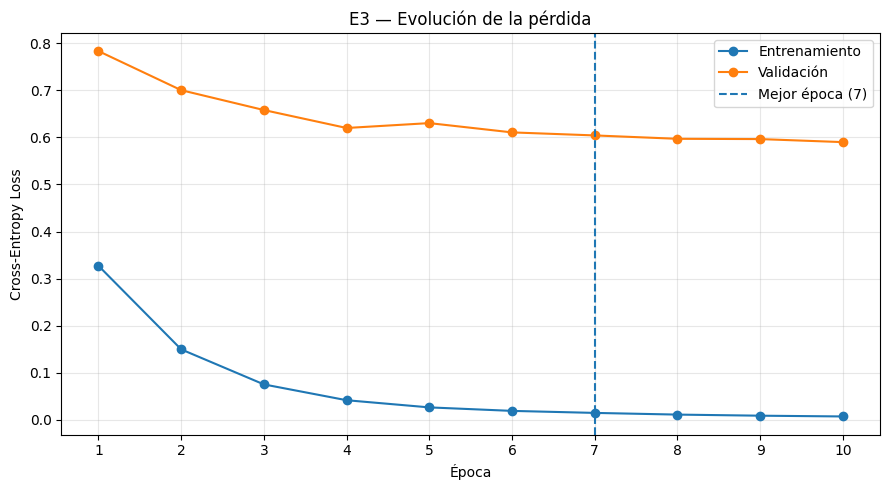

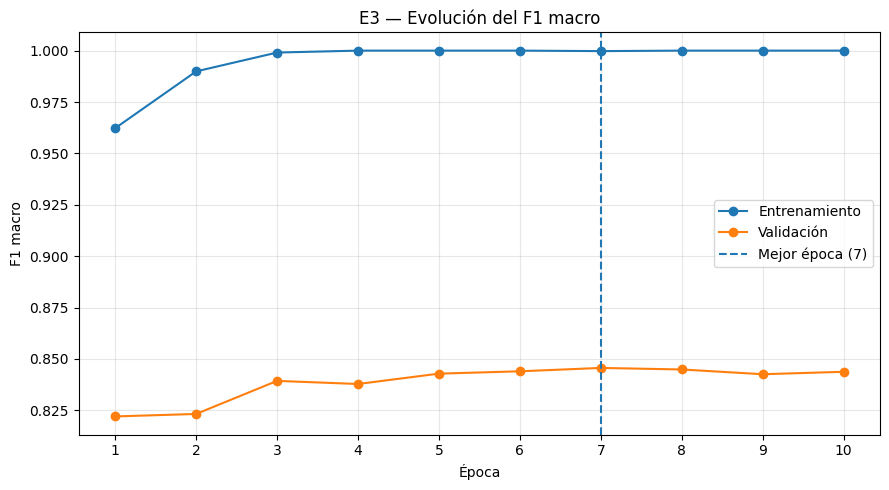

In [28]:
import matplotlib.pyplot as plt


history_df = pd.read_csv(
    OUTPUT_DIR / "finetuning_history.csv"
)

# Curva de pérdida

plt.figure(figsize=(9, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Entrenamiento"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validación"
)

plt.axvline(
    x=best_epoch,
    linestyle="--",
    label=f"Mejor época ({best_epoch})"
)

plt.xlabel("Época")
plt.ylabel("Cross-Entropy Loss")
plt.title("E3 — Evolución de la pérdida")
plt.xticks(history_df["epoch"])
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Curva de F1 macro

plt.figure(figsize=(9, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_f1_macro"],
    marker="o",
    label="Entrenamiento"
)

plt.plot(
    history_df["epoch"],
    history_df["val_f1_macro"],
    marker="o",
    label="Validación"
)

plt.axvline(
    x=best_epoch,
    linestyle="--",
    label=f"Mejor época ({best_epoch})"
)

plt.xlabel("Época")
plt.ylabel("F1 macro")
plt.title("E3 — Evolución del F1 macro")
plt.xticks(history_df["epoch"])
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# **14. Cargar el mejor checkpoint**

In [29]:
import torch

checkpoint_path = OUTPUT_DIR / "best_bioclip_finetuning.pt"

checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False
)

finetuning_model.load_state_dict(
    checkpoint["model_state_dict"]
)

finetuning_model.to(device)
finetuning_model.eval()

print("=== Checkpoint cargado ===")
print(f"Época seleccionada: {checkpoint['epoch']}")
print(
    "F1 macro de validación: "
    f"{checkpoint['val_f1_macro']:.4f}"
)
print(f"Modelo en modo evaluación: {not finetuning_model.training}")
print(f"Dispositivo: {device}")

=== Checkpoint cargado ===
Época seleccionada: 7
F1 macro de validación: 0.8456
Modelo en modo evaluación: True
Dispositivo: cuda


# **15. Evaluación del conjunto de prueba**

In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import numpy as np
import pandas as pd
import json

finetuning_model.eval()

all_test_predictions = []
all_test_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = finetuning_model(images)
        predictions = torch.argmax(logits, dim=1)

        all_test_predictions.extend(
            predictions.cpu().numpy()
        )
        all_test_labels.extend(
            labels.cpu().numpy()
        )

# Métricas globales

test_metrics = {
    "experiment": "E3",
    "model": "BioCLIP ViT-B/16",
    "strategy": "Light Fine-Tuning",
    "selected_epoch": int(checkpoint["epoch"]),
    "accuracy": accuracy_score(
        all_test_labels, all_test_predictions
    ),
    "precision_macro": precision_score(
        all_test_labels,
        all_test_predictions,
        average="macro",
        zero_division=0
    ),
    "recall_macro": recall_score(
        all_test_labels,
        all_test_predictions,
        average="macro",
        zero_division=0
    ),
    "f1_macro": f1_score(
        all_test_labels,
        all_test_predictions,
        average="macro",
        zero_division=0
    ),
    "f1_weighted": f1_score(
        all_test_labels,
        all_test_predictions,
        average="weighted",
        zero_division=0
    )
}

print("=== E3 — Métricas en test ===")
for metric, value in test_metrics.items():
    if isinstance(value, float):
        print(f"{metric}: {value:.4f}")
    else:
        print(f"{metric}: {value}")

# Reporte por clase

class_names = (
    test_df.sort_values("class_id")
    .drop_duplicates("class_id")["class_name"]
    .tolist()
)

class_ids = list(range(NUM_CLASSES))

report_dict = classification_report(
    all_test_labels,
    all_test_predictions,
    labels=class_ids,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

print("\n=== Reporte de clasificación ===")
display(report_df)

# Matriz de confusión

cm = confusion_matrix(
    all_test_labels,
    all_test_predictions,
    labels=class_ids
)

print(f"\nMatriz de confusión: {cm.shape}")

# Guardar resultados

predictions_df = pd.DataFrame({
    "true_label": all_test_labels,
    "predicted_label": all_test_predictions,
    "true_class": [
        class_names[i] for i in all_test_labels
    ],
    "predicted_class": [
        class_names[i] for i in all_test_predictions
    ]
})

predictions_df.to_csv(
    OUTPUT_DIR / "finetuning_test_predictions.csv",
    index=False
)

report_df.to_csv(
    OUTPUT_DIR / "finetuning_test_classification_report.csv"
)

np.save(
    OUTPUT_DIR / "finetuning_test_confusion_matrix.npy",
    cm
)

with open(
    OUTPUT_DIR / "finetuning_test_metrics.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(test_metrics, f, indent=4, ensure_ascii=False)

print("\nResultados guardados en:")
print(OUTPUT_DIR)

=== E3 — Métricas en test ===
experiment: E3
model: BioCLIP ViT-B/16
strategy: Light Fine-Tuning
selected_epoch: 7
accuracy: 0.8739
precision_macro: 0.8964
recall_macro: 0.8748
f1_macro: 0.8738
f1_weighted: 0.8728

=== Reporte de clasificación ===


,precision,recall,f1-score,support
Achnatherum inebrians,1.000000,1.000000,1.000000,6.000000
Achnatherum splendens,1.000000,0.833333,0.909091,6.000000
Agriophyllum squarrosum,0.923077,0.923077,0.923077,13.000000
Agropyron cristatum,0.454545,0.625000,0.526316,8.000000
Agropyron elongatum,0.857143,1.000000,0.923077,6.000000
...,...,...,...,...
Vicia villosa,1.000000,0.833333,0.909091,6.000000
Zygophyllum xanthoxylon,1.000000,1.000000,1.000000,7.000000
accuracy,0.873887,0.873887,0.873887,0.873887
macro avg,0.896432,0.874784,0.873821,674.000000



Matriz de confusión: (88, 88)

Resultados guardados en:
/content/drive/MyDrive/dataset-LZUPSD/finetuning_outputs


# **16. Tablas Comprativas (Zero-Shot vs Fine Tuning Ligero)**

In [31]:
comparison_df = pd.DataFrame([
    {
        "experiment": "E2",
        "strategy": "Linear Probe",
        "accuracy": 0.9036,
        "precision_macro": 0.9143,
        "recall_macro": 0.8988,
        "f1_macro": 0.8992,
        "f1_weighted": 0.9032
    },
    {
        "experiment": "E3",
        "strategy": "Light Fine-Tuning",
        "accuracy": test_metrics["accuracy"],
        "precision_macro": test_metrics["precision_macro"],
        "recall_macro": test_metrics["recall_macro"],
        "f1_macro": test_metrics["f1_macro"],
        "f1_weighted": test_metrics["f1_weighted"]
    }
])

print("=== Comparación E2 vs E3 ===")
display(
    comparison_df.style.format({
        "accuracy": "{:.4f}",
        "precision_macro": "{:.4f}",
        "recall_macro": "{:.4f}",
        "f1_macro": "{:.4f}",
        "f1_weighted": "{:.4f}"
    })
)

comparison_path = OUTPUT_DIR / "E2_vs_E3_comparison.csv"

comparison_df.to_csv(
    comparison_path,
    index=False
)

print(f"\nComparación guardada en:")
print(comparison_path)

=== Comparación E2 vs E3 ===


,experiment,strategy,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,E2,Linear Probe,0.9036,0.9143,0.8988,0.8992,0.9032
1,E3,Light Fine-Tuning,0.8739,0.8964,0.8748,0.8738,0.8728



Comparación guardada en:
/content/drive/MyDrive/dataset-LZUPSD/finetuning_outputs/E2_vs_E3_comparison.csv


In [32]:
import numpy as np
import pandas as pd


cm = np.load(
    OUTPUT_DIR / "finetuning_test_confusion_matrix.npy"
)


errors_per_class = []

for class_id in range(NUM_CLASSES):

    total_samples = cm[class_id].sum()
    correct = cm[class_id, class_id]
    errors = total_samples - correct

    accuracy_class = (
        correct / total_samples
        if total_samples > 0
        else 0
    )

    errors_per_class.append({
        "class_id": class_id,
        "class_name": class_names[class_id],
        "samples": total_samples,
        "correct": correct,
        "errors": errors,
        "accuracy": accuracy_class
    })

errors_df = pd.DataFrame(errors_per_class)


worst_by_errors = (
    errors_df
    .sort_values(
        ["errors", "accuracy"],
        ascending=[False, True]
    )
    .head(15)
)

print("=== 15 clases con más errores ===")

display(
    worst_by_errors.style.format({
        "accuracy": "{:.2%}"
    })
)


confusions = []

for true_id in range(NUM_CLASSES):

    for predicted_id in range(NUM_CLASSES):

        if true_id == predicted_id:
            continue

        count = cm[true_id, predicted_id]

        if count > 0:
            confusions.append({
                "true_class": class_names[true_id],
                "predicted_class": class_names[predicted_id],
                "errors": int(count)
            })

confusions_df = pd.DataFrame(confusions)

confusions_df = (
    confusions_df
    .sort_values("errors", ascending=False)
    .reset_index(drop=True)
)

print("\n=== 20 principales confusiones ===")

display(
    confusions_df.head(20)
)


total_errors = int(
    cm.sum() - np.trace(cm)
)

total_samples = int(cm.sum())

print("\n=== Resumen ===")
print(f"Total de muestras: {total_samples}")
print(f"Predicciones correctas: {int(np.trace(cm))}")
print(f"Predicciones incorrectas: {total_errors}")
print(f"Accuracy: {np.trace(cm) / cm.sum():.4f}")

=== 15 clases con más errores ===


,class_id,class_name,samples,correct,errors,accuracy
63,63,Melilotus officinalis,8,3,5,37.50%
79,79,Setaria viridis,7,3,4,42.86%
42,42,Halimodendron halodendron,8,4,4,50.00%
17,17,Avena sativa,9,5,4,55.56%
54,54,Lespedeza daurica,15,11,4,73.33%
24,24,Caragana liouana,6,3,3,50.00%
25,25,Caragana microphylla,6,3,3,50.00%
43,43,Halogeton arachnoideus,7,4,3,57.14%
66,66,Oxytropis bicolor,7,4,3,57.14%
3,3,Agropyron cristatum,8,5,3,62.50%



=== 20 principales confusiones ===


,true_class,predicted_class,errors
0,Avena sativa,Agropyron cristatum,3
1,Oxytropis bicolor,Kochia scoparia,3
2,Setaria viridis,Artemisia desertorum,3
3,Poa annua,Puccinellia distans,3
4,Agropyron cristatum,Elymus sibiricus,2
5,Lespedeza daurica,Astragalus melilotoides,2
6,Halimodendron halodendron,Lespedeza bicolor,2
7,Melilotus officinalis,Lycium ruthenicum,2
8,Caragana microphylla,Caragana liouana,2
9,Festuca rubra,Agropyron mongolicum,2



=== Resumen ===
Total de muestras: 674
Predicciones correctas: 589
Predicciones incorrectas: 85
Accuracy: 0.8739


In [33]:
print("=== 15 CLASES CON MÁS ERRORES ===\n")

for _, row in worst_by_errors.iterrows():

    print(
        f"{int(row['class_id']):2d} | "
        f"{row['class_name']} | "
        f"Muestras: {int(row['samples']):2d} | "
        f"Correctas: {int(row['correct']):2d} | "
        f"Errores: {int(row['errors']):2d} | "
        f"Accuracy: {row['accuracy']:.2%}"
    )


print("\n" + "=" * 80)
print("=== 20 PRINCIPALES CONFUSIONES ===\n")

for i, row in confusions_df.head(20).iterrows():

    print(
        f"{i + 1:2d}. "
        f"Real: {row['true_class']} "
        f"→ Predicha: {row['predicted_class']} "
        f"| Errores: {int(row['errors'])}"
    )

=== 15 CLASES CON MÁS ERRORES ===

63 | Melilotus officinalis | Muestras:  8 | Correctas:  3 | Errores:  5 | Accuracy: 37.50%
79 | Setaria viridis | Muestras:  7 | Correctas:  3 | Errores:  4 | Accuracy: 42.86%
42 | Halimodendron halodendron | Muestras:  8 | Correctas:  4 | Errores:  4 | Accuracy: 50.00%
17 | Avena sativa | Muestras:  9 | Correctas:  5 | Errores:  4 | Accuracy: 55.56%
54 | Lespedeza daurica | Muestras: 15 | Correctas: 11 | Errores:  4 | Accuracy: 73.33%
24 | Caragana liouana | Muestras:  6 | Correctas:  3 | Errores:  3 | Accuracy: 50.00%
25 | Caragana microphylla | Muestras:  6 | Correctas:  3 | Errores:  3 | Accuracy: 50.00%
43 | Halogeton arachnoideus | Muestras:  7 | Correctas:  4 | Errores:  3 | Accuracy: 57.14%
66 | Oxytropis bicolor | Muestras:  7 | Correctas:  4 | Errores:  3 | Accuracy: 57.14%
 3 | Agropyron cristatum | Muestras:  8 | Correctas:  5 | Errores:  3 | Accuracy: 62.50%
59 | Lycium chinese | Muestras:  8 | Correctas:  5 | Errores:  3 | Accuracy: 62.5

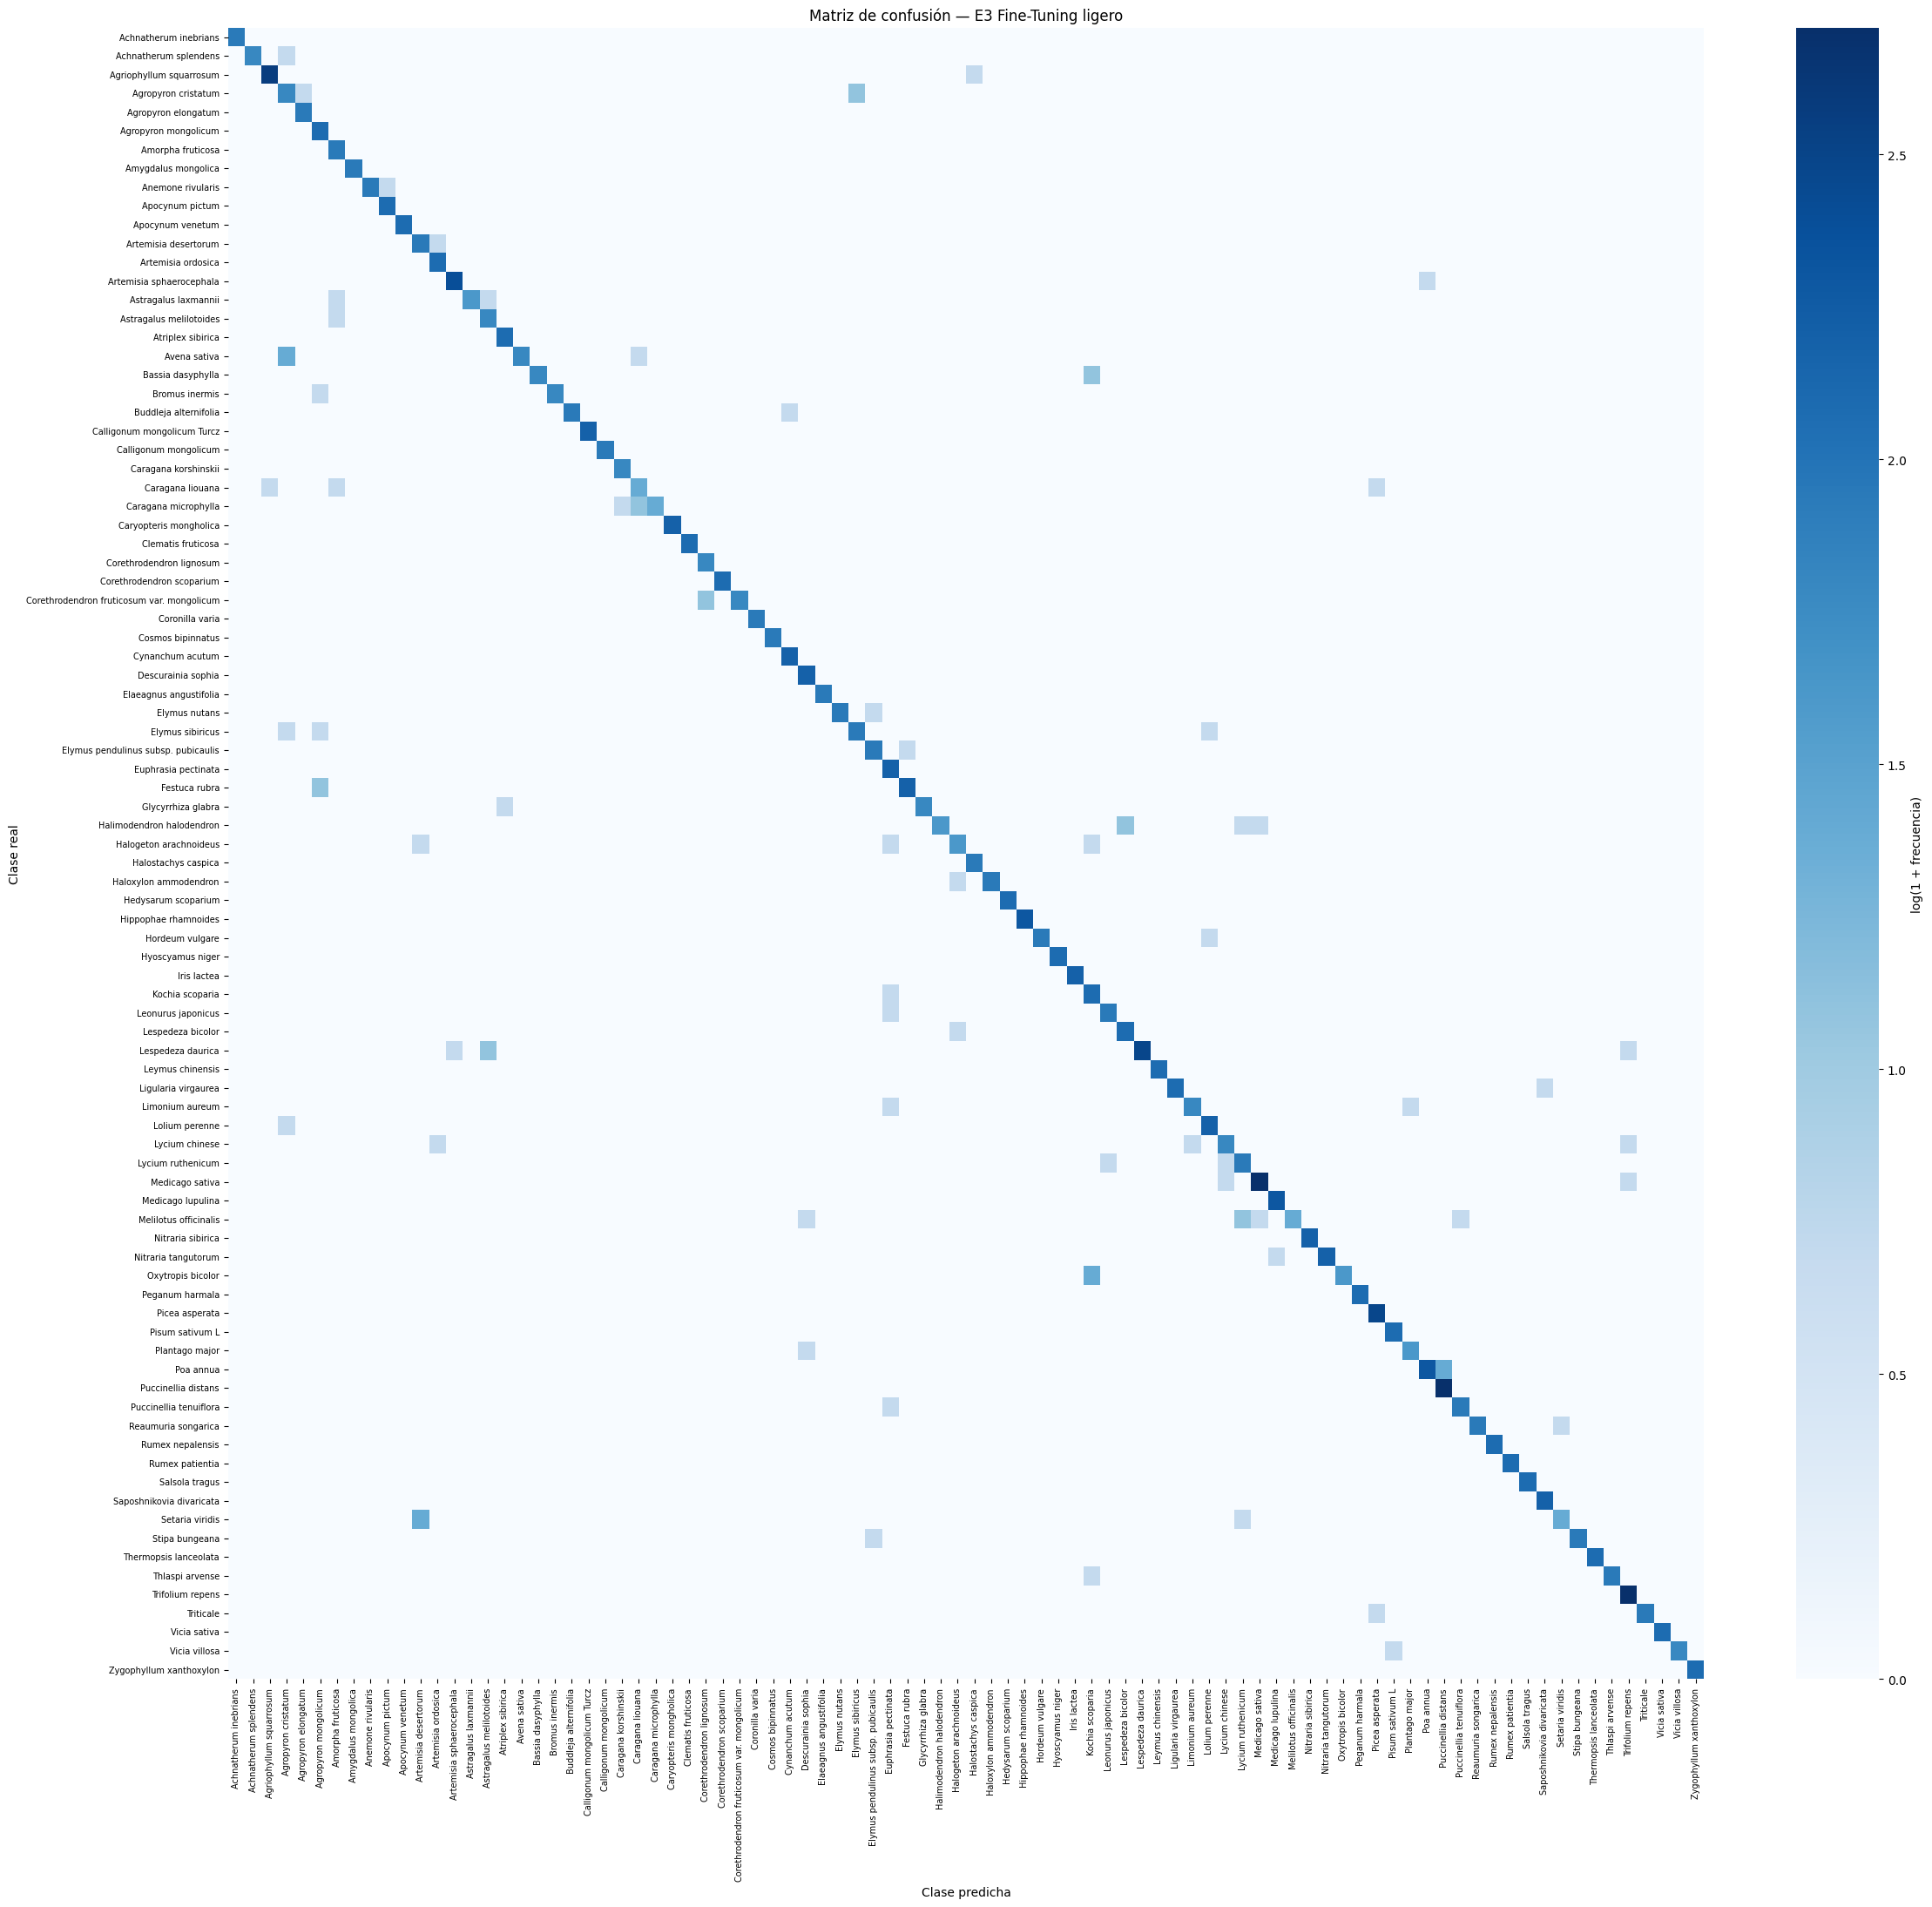

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar matriz de confusión
cm = np.load(
    "/content/drive/MyDrive/dataset-LZUPSD/finetuning_outputs/"
    "finetuning_test_confusion_matrix.npy"
)

# Obtener nombres de las clases en orden de class_id
class_names = (
    train_df[["class_id", "class_name"]]
    .drop_duplicates()
    .sort_values("class_id")["class_name"]
    .tolist()
)

plt.figure(figsize=(24, 22))

# Transformación logarítmica para facilitar la visualización
cm_log = np.log1p(cm)

sns.heatmap(
    cm_log,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={"label": "log(1 + frecuencia)"}
)

plt.title("Matriz de confusión — E3 Fine-Tuning ligero")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")

plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)

plt.tight_layout()
plt.show()